![elpretty](AI.jpg)
# 🧠 Técnicas de Inteligencia Artificial (TIA)
## 📝 Taller 3: Diseño y Optimización de un MLP Profundo

---

### 👤 Información del Proyecto
*   **Materia:** Técnicas de Inteligencia Artificial
*   **Actividad:** Taller 3 - Reconocimiento con Perceptrón Multicapa (MLP)
*   **Dataset:** 🎭 [Olivetti Faces](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html)

---

### 🎯 Objetivo General
Diseñar, entrenar y optimizar un **Perceptrón Multicapa (MLP)** profundo, sin utilizar redes convolucionales (CNN), para identificar personas en un problema de clasificación multiclase utilizando el dataset de rostros Olivetti.

### 🚀 Tecnologías Utilizadas
*   ![Python](https://img.shields.io/badge/python-3670A0?style=for-the-badge&logo=python&logoColor=ffdd54)
*   ![Scikit-Learn](https://img.shields.io/badge/scikit--learn-%23F7931E.svg?style=for-the-badge&logo=scikit-learn&logoColor=white)
*   ![NumPy](https://img.shields.io/badge/numpy-%23013243.svg?style=for-the-badge&logo=numpy&logoColor=white)
*   ![Matplotlib](https://img.shields.io/badge/Matplotlib-%23ffffff.svg?style=for-the-badge&logo=Matplotlib&logoColor=black)

---

### 📂 Estructura de la Partición de Datos
Para garantizar la robustez del modelo, se ha aplicado la técnica de **Hold-out** con **Muestreo Estratificado**:
*   **60%** Entrenamiento 🏋️‍♂️
*   **20%** Validación ⚖️
*   **20%** Prueba 🏁

---


## 🛠️ Preparación y Preprocesamiento de Datos

En esta etapa, preparamos el dataset **Olivetti Faces** para que pueda ser procesado eficientemente por nuestro modelo de Red Neuronal (MLP).

### 1. 📊 Descripción del Dataset
*   **Contenido:** 400 imágenes de rostros en escala de grises.
*   **Clases:** 40 personas distintas (10 imágenes por persona).
*   **Dimensiones:** Cada imagen es de $64 \times 64$ píxeles, lo que resulta en un vector de características de entrada de **4096** dimensiones.

### 2. ✂️ Estrategia de Partición (Hold-out)
Para evaluar el rendimiento del modelo de forma objetiva, dividimos el total de datos en tres subconjuntos independientes utilizando **Muestreo Estratificado (Stratified Sampling)**:

| Subconjunto | Porcentaje | Propósito |
| :--- | :---: | :--- |
| **Entrenamiento (Train)** | 60% | Ajustar los pesos de la red neuronal. |
| **Validación (Val)** | 20% | Ajustar hiperparámetros y prevenir el sobreajuste (overfitting). |
| **Prueba (Test)** | 20% | Evaluación final del modelo con datos nunca antes vistos. |

> **Nota:** La estratificación garantiza que cada una de las 40 personas mantenga exactamente la misma proporción de imágenes en cada set (6 train, 2 val, 2 test), evitando sesgos por la falta de ejemplos de alguna clase.

### 3. 🧪 Normalización Z-score (Estandarización)
Se aplica la **Estandarización** para que cada característica (píxel) tenga una media de **0** y una desviación estándar de **1**.

*   **Técnica:** $z = \frac{x - \mu}{\sigma}$
*   **Regla de Oro:** El escalador se entrena (`fit`) únicamente con los datos de entrenamiento para evitar el **Data Leakage** (fuga de información desde el conjunto de prueba).

---


In [5]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Cargar el dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = faces.data, faces.target

# 2. División estratificada (60% Train, 20% Val, 20% Test)
semilla = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=semilla, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=semilla, stratify=y_temp
)

# 3. Verificación
print(f"Entrenamiento: {len(X_train)} | Validación: {len(X_val)} | Prueba: {len(X_test)}")


Entrenamiento: 240 | Validación: 80 | Prueba: 80


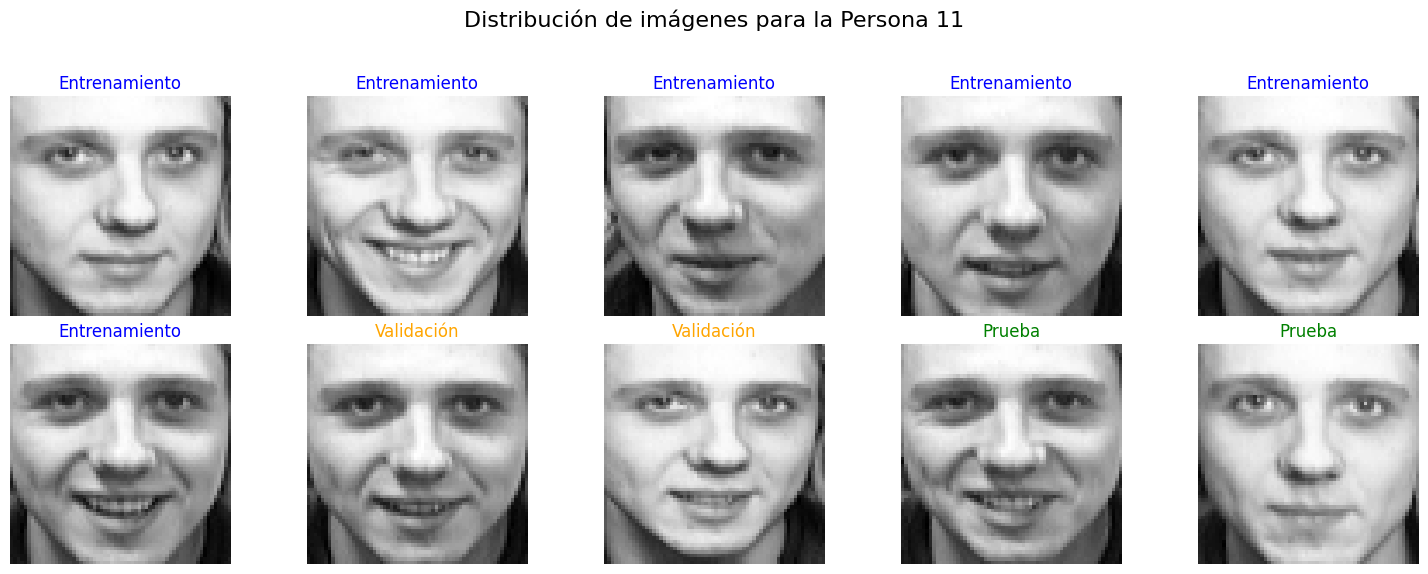

In [38]:
import matplotlib.pyplot as plt

def visualizar_distribucion_clase(id_persona=0):
    """Muestra las 10 fotos de una persona y en qué set quedaron"""
    # Encontrar los índices en cada set para esa persona
    idx_train = np.where(y_train == id_persona)[0]
    idx_val = np.where(y_val == id_persona)[0]
    idx_test = np.where(y_test == id_persona)[0]
    
    # Recopilar imágenes y sus etiquetas de origen
    imagenes = [X_train[i] for i in idx_train] + [X_val[i] for i in idx_val] + [X_test[i] for i in idx_test]
    labels = ["Entrenamiento"]*len(idx_train) + ["Validación"]*len(idx_val) + ["Prueba"]*len(idx_test)
    
    # Crear el grid de 2x5 (total 10 imágenes por persona)
    plt.figure(figsize=(15, 6))
    plt.suptitle(f"Distribución de imágenes para la Persona {id_persona}", fontsize=16)
    
    for i in range(len(imagenes)):
        plt.subplot(2, 5, i + 1)
        plt.imshow(imagenes[i].reshape(64, 64), cmap='gray')
        color_label = 'blue' if labels[i] == "Entrenamiento" else ('orange' if labels[i] == "Validación" else 'green')
        plt.title(labels[i], color=color_label)

        plt.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Visualizamos la Persona 0 para comprobar la estratificación (6 Train, 2 Val, 2 Test)
visualizar_distribucion_clase(id_persona=11)


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Instanciar el escalador para Normalización Z-score
# Esto restará la media y dividirá por la desviación estándar: (x - u) / s
scaler = StandardScaler()

# 2. Ajustar el escalador ÚNICAMENTE con el conjunto de entrenamiento (fit)
# Es CRUCIAL no incluir validación ni prueba aquí para evitar que el modelo 
# "conozca" la distribución de los datos que usaremos para evaluar.
scaler.fit(X_train)

# 3. Transformar los tres conjuntos de forma coherente
# Usamos la media y desviación calculadas solo con el set de entrenamiento
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. Verificación técnica de la normalización
print("Validación de la Normalización Z-score:")
print(f"-> Entrenamiento - Media: {X_train_scaled.mean():.2f} | Desv. Estándar: {X_train_scaled.std():.2f}")
print(f"-> Validación    - Media: {X_val_scaled.mean():.2f} | Desv. Estándar: {X_val_scaled.std():.2f}")
print(f"-> Prueba        - Media: {X_test_scaled.mean():.2f} | Desv. Estándar: {X_test_scaled.std():.2f}")

# A partir de ahora, usaremos las variables '_scaled' para alimentar la red neuronal (MLP)


Validación de la Normalización Z-score:
-> Entrenamiento - Media: 0.00 | Desv. Estándar: 1.00
-> Validación    - Media: -0.02 | Desv. Estándar: 1.00
-> Prueba        - Media: 0.02 | Desv. Estándar: 1.00


## 🧠 Justificación del Espacio de Búsqueda y Diseño

En lugar de un diseño estático, se implementó una **Búsqueda Aleatoria (Random Search)** para explorar la combinación óptima de hiperparámetros basada en tres perfiles estratégicos:

### 1. Arquitectura y Capacidad
*   **Estructura Variable (2 a 4 capas):** Se exploraron profundidades de 2 a 4 capas ocultas con neuronas entre 64 y 1024. Esto permite que el sistema decida si el problema se resuelve mejor con una red ancha (Robusto) o una red más estrecha y profunda (Profundo).
*   **Regularización (Dropout y L2):** Se integraron capas de **Dropout (0.3 - 0.5)** y penalización **L2 (Weight Decay)** para mitigar el sobreajuste, factor crítico dado el tamaño reducido del dataset Olivetti.

### 2. Funciones de Activación
*   **ReLU, SELU y LeakyReLU:** Se evaluaron distintas activaciones. La **ReLU** se usó por su eficiencia, la **SELU** por su capacidad de auto-normalización en redes profundas, y la **LeakyReLU** para evitar el problema de "neuronas muertas" durante el entrenamiento adaptativo.
*   **Softmax:** Crucial en la capa de salida para obtener una distribución de probabilidad sobre las 40 identidades.

### 3. Función de Pérdida y Optimización
*   **Sparse Categorical Crossentropy:** Función de pérdida estándar para clasificación multiclase con etiquetas enteras.
*   **Optimizadores Adaptativos (Adam, AdamW, RMSprop):** Se seleccionaron estos optimizadores por su capacidad de ajustar la tasa de aprendizaje (`learning_rate`) de forma dinámica. El uso de **AdamW** en particular permite desacoplar el decaimiento de pesos de la actualización del gradiente, mejorando la generalización.


In [15]:
import numpy as np
import time
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.initializers import HeNormal, LecunNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fijamos semillas para que los números "aleatorios" sean idénticos si lo vuelves a correr
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


In [16]:
def build_model(profile, lr, dropout_rate=None, l2_reg=None, neurons_list=[]):
    model = Sequential()
    model.add(Input(shape=(4096,)))
    
    if profile == 'Robusto':
        # Perfil Robusto: ReLU, HeNormal, Dropout, Adam
        for units in neurons_list:
            model.add(Dense(units, activation='relu', kernel_initializer=HeNormal()))
            model.add(Dropout(dropout_rate))
        optimizer = Adam(learning_rate=lr)
        
    elif profile == 'Profundo':
        # Perfil Profundo: SELU, LecunNormal, L2 Weight Decay, AdamW
        for units in neurons_list:
            model.add(Dense(units, activation='selu', kernel_initializer=LecunNormal(), kernel_regularizer=l2(l2_reg)))
        
        # Uso de AdamW (Fallback a Adam si la versión de TF es muy antigua)
        try:
            from tensorflow.keras.optimizers import AdamW
            optimizer = AdamW(learning_rate=lr, weight_decay=l2_reg)
        except ImportError:
            optimizer = Adam(learning_rate=lr) 
                
    elif profile == 'Adaptativo':
        # Perfil Adaptativo: LeakyReLU, HeNormal, RMSprop
        for units in neurons_list:
            model.add(Dense(units, kernel_initializer=HeNormal()))
            model.add(LeakyReLU(alpha=0.1))
        optimizer = RMSprop(learning_rate=lr)
        
    # Capa de salida común: 40 clases, Softmax
    model.add(Dense(40, activation='softmax'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


## 🔎 Optimización de Hiperparámetros (Random Search)

Dado que un MLP tiene múltiples configuraciones posibles, no nos limitamos a un solo diseño. Hemos implementado una **Búsqueda Aleatoria de 50 iteraciones** explorando tres perfiles arquitectónicos distintos para encontrar el balance óptimo:

1.  **Perfil Robusto 🛡️:** Enfoque en regularización agresiva con **Dropout (0.3 - 0.5)** y funciones **ReLU**. Ideal para evitar el sobreajuste en este dataset pequeño.
2.  **Perfil Profundo 🏗️:** Aumenta la profundidad (3-4 capas) usando activaciones **SELU** y regularización **L2 (Weight Decay)**, optimizado con **AdamW**.
3.  **Perfil Adaptativo 📉:** Utiliza **LeakyReLU** y un **Scheduler (ReduceLROnPlateau)** que reduce la tasa de aprendizaje si el modelo deja de mejorar, permitiendo un ajuste fino al final del entrenamiento.

El sistema selecciona automáticamente los **3 mejores modelos** basándose exclusivamente en su desempeño con datos de validación.


In [17]:
NUM_ITERACIONES = 50
PACIENCIA = 12

resultados = []
print(f"Iniciando Búsqueda Aleatoria ({NUM_ITERACIONES} iteraciones)...\n")

for i in range(NUM_ITERACIONES):
    profile = random.choice(['Robusto', 'Profundo', 'Adaptativo'])
    lr = 10 ** np.random.uniform(-5, -2) # Tasa logarítmica
    
    # Callback base
    callbacks = [EarlyStopping(monitor='val_loss', patience=PACIENCIA, restore_best_weights=True)]
    kwargs = {}
    
    # Muestreo de hiperparámetros según el perfil
    if profile == 'Robusto':
        kwargs['dropout_rate'] = np.random.uniform(0.3, 0.5)
        n1 = random.choice([256, 512, 1024])
        n2 = random.choice([128, 256]) # Segunda capa
        kwargs['neurons_list'] = [n1, n2]
        
    elif profile == 'Profundo':
        kwargs['l2_reg'] = 10 ** np.random.uniform(-6, -3)
        num_layers = random.choice([3, 4])
        kwargs['neurons_list'] = [512, 256, 128, 64][:num_layers]
        
    elif profile == 'Adaptativo':
        num_layers = random.choice([2, 3])
        kwargs['neurons_list'] = [512, 256, 128][:num_layers]
        # Scheduler exclusivo para Adaptativo
        callbacks.append(ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6))

    # Entrenar
    model = build_model(profile, lr, **kwargs)
    start_time = time.time()
    
    history = model.fit(
        X_train_scaled, y_train,
        epochs=150, batch_size=32,
        validation_data=(X_val_scaled, y_val),
        callbacks=callbacks, verbose=0 # Verbose 0 para salida limpia
    )
    tiempo_train = time.time() - start_time
    
    # Métricas del mejor momento (guardado por restore_best_weights)
    val_acc_best = max(history.history['val_accuracy'])
    val_loss_best = min(history.history['val_loss'])
    
    resultados.append({
        'Iteración': i + 1, 'Perfil': profile, 'LR': lr,
        'Hiperparámetros': str(kwargs), 'Val_Accuracy': val_acc_best,
        'Val_Loss': val_loss_best, 'Tiempo (s)': tiempo_train,
        'Historia': history.history, 'Pesos': model.get_weights(), 'kwargs': kwargs
    })
    
    print(f"Iter {i+1:02d} | Perfil: {profile:10s} | Val Acc: {val_acc_best:.4f} | Tiempo: {tiempo_train:.1f}s")

# Selección del Top 3
df_resultados = pd.DataFrame(resultados).drop(columns=['Historia', 'Pesos', 'kwargs'])
df_top3 = df_resultados.sort_values(by='Val_Accuracy', ascending=False).head(3).reset_index(drop=True)

print("\n🏆 --- TABLA COMPARATIVA: TOP 3 MODELOS --- 🏆")
display(df_top3)


Iniciando Búsqueda Aleatoria (50 iteraciones)...



C:\Users\aiize\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Iter 01 | Perfil: Adaptativo | Val Acc: 0.9500 | Tiempo: 23.5s
Iter 02 | Perfil: Robusto    | Val Acc: 0.3625 | Tiempo: 5.5s
Iter 03 | Perfil: Adaptativo | Val Acc: 0.9625 | Tiempo: 21.3s
Iter 04 | Perfil: Robusto    | Val Acc: 0.9375 | Tiempo: 14.8s
Iter 05 | Perfil: Robusto    | Val Acc: 0.9750 | Tiempo: 45.0s
Iter 06 | Perfil: Robusto    | Val Acc: 0.9750 | Tiempo: 4.5s
Iter 07 | Perfil: Profundo   | Val Acc: 0.9500 | Tiempo: 31.6s
Iter 08 | Perfil: Profundo   | Val Acc: 0.8625 | Tiempo: 7.0s
Iter 09 | Perfil: Robusto    | Val Acc: 0.9500 | Tiempo: 23.6s
Iter 10 | Perfil: Profundo   | Val Acc: 0.9500 | Tiempo: 30.9s
Iter 11 | Perfil: Robusto    | Val Acc: 0.9375 | Tiempo: 8.9s
Iter 12 | Perfil: Profundo   | Val Acc: 0.9500 | Tiempo: 31.5s
Iter 13 | Perfil: Profundo   | Val Acc: 0.9500 | Tiempo: 33.6s
Iter 14 | Perfil: Adaptativo | Val Acc: 0.9500 | Tiempo: 23.8s
Iter 15 | Perfil: Adaptativo | Val Acc: 0.8875 | Tiempo: 3.1s
Iter 16 | Perfil: Profundo   | Val Acc: 0.9250 | Tiempo: 34.

,Iteración,Perfil,LR,Hiperparámetros,Val_Accuracy,Val_Loss,Tiempo (s)
0,25,Robusto,0.000306,"{'dropout_rate': 0.30687770422304367, 'neurons...",0.9875,0.073048,13.060978
1,5,Robusto,0.000015,"{'dropout_rate': 0.47323522915498706, 'neurons...",0.9750,0.233743,45.010163
2,32,Robusto,0.002115,"{'dropout_rate': 0.4878997883128378, 'neurons_...",0.9750,0.130801,6.006195


## 🏆 Evaluación de los Mejores Modelos

Para los 3 modelos ganadores, realizamos una evaluación exhaustiva que incluye:

*   **Curvas de Aprendizaje:** Comparación de la pérdida (*Loss*) y precisión (*Accuracy*) entre entrenamiento y validación para verificar la estabilidad del modelo.
*   **Métricas Globales:** Cálculo de **Accuracy, Precision, Recall y F1-score** en el conjunto de prueba (datos nunca antes vistos).
*   **Matriz de Confusión:** Visualización de los aciertos y errores por clase para identificar si existen identidades específicas que el modelo tiende a confundir.



🥇 RANK 1 | Perfil: Robusto | TEST Accuracy: 0.9500
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      

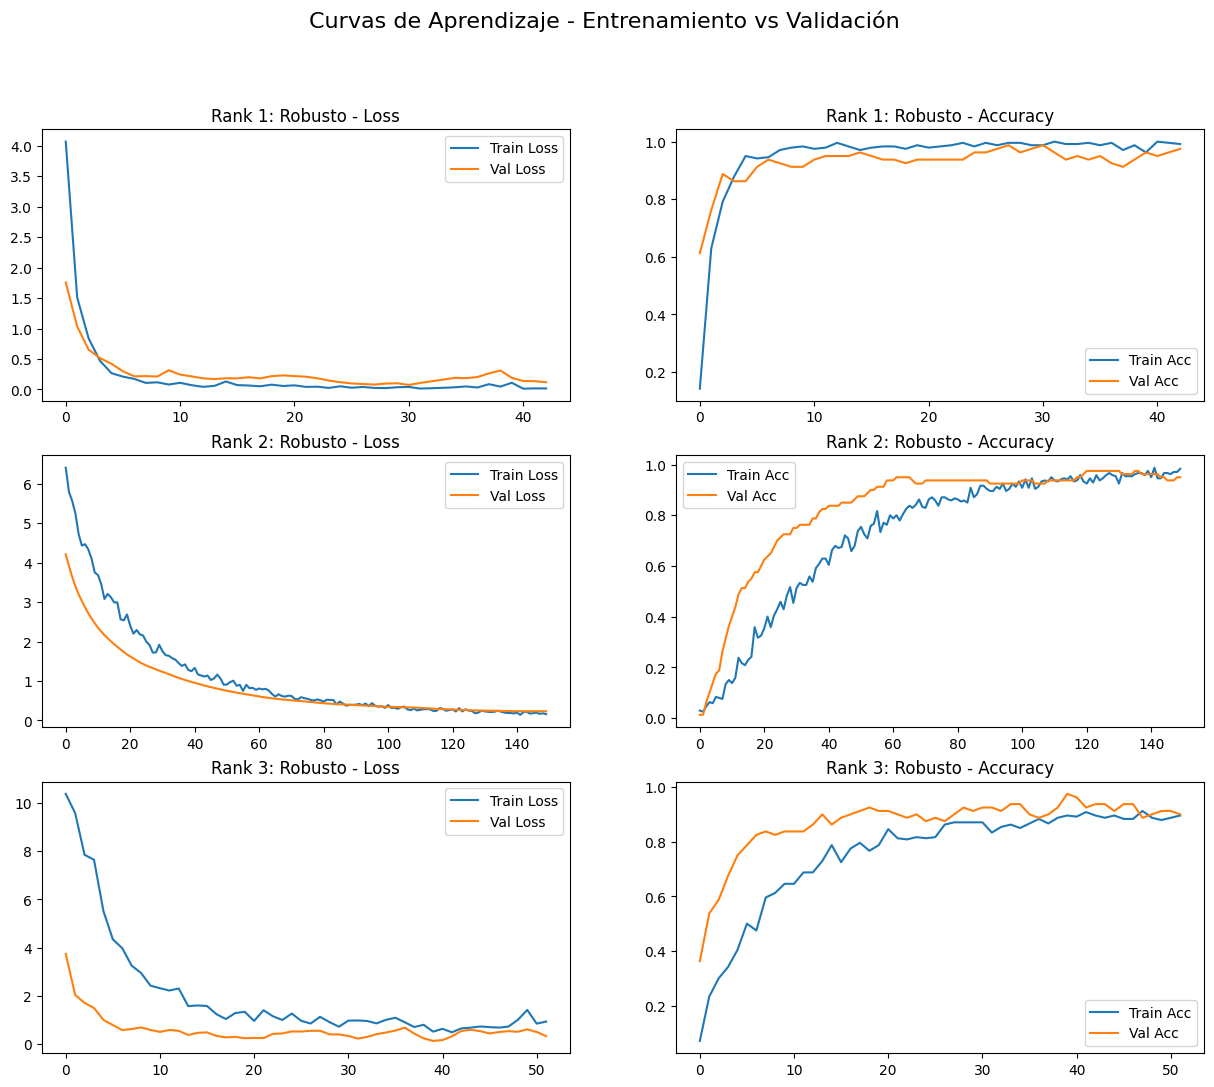

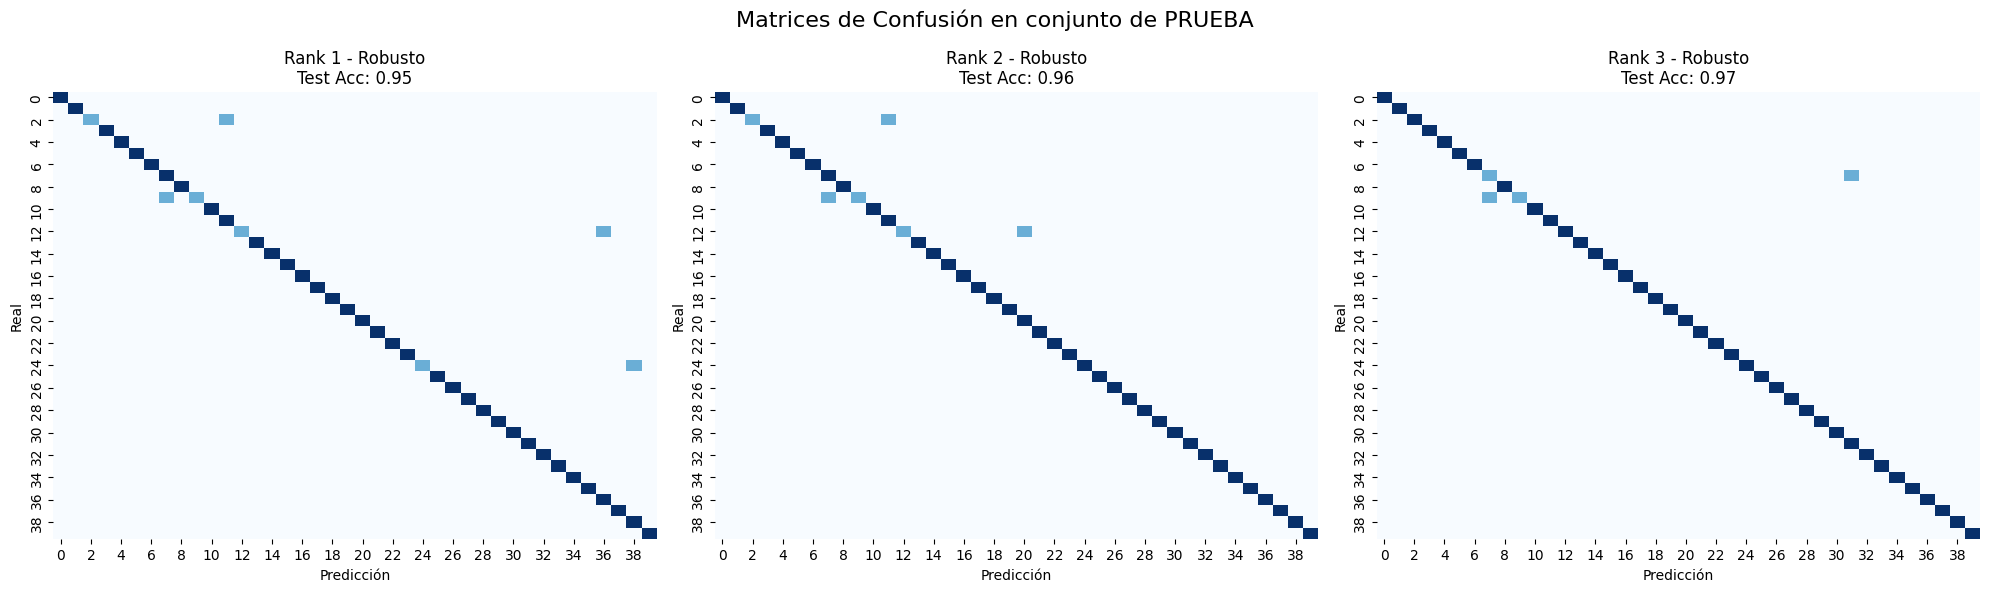

In [18]:
# Preparar figuras
fig_curves, axes_curves = plt.subplots(3, 2, figsize=(15, 12))
fig_curves.suptitle('Curvas de Aprendizaje - Entrenamiento vs Validación', fontsize=16)

fig_cm, axes_cm = plt.subplots(1, 3, figsize=(20, 6))
fig_cm.suptitle('Matrices de Confusión en conjunto de PRUEBA', fontsize=16)

for idx, row in df_top3.iterrows():
    datos_modelo = next(item for item in resultados if item["Iteración"] == row["Iteración"])
    
    # Reconstruir modelo ganador
    modelo_ganador = build_model(datos_modelo['Perfil'], datos_modelo['LR'], **datos_modelo['kwargs'])
    modelo_ganador.set_weights(datos_modelo['Pesos'])
    
    hist = datos_modelo['Historia']
    
    # Graficar Loss
    axes_curves[idx, 0].plot(hist['loss'], label='Train Loss')
    axes_curves[idx, 0].plot(hist['val_loss'], label='Val Loss')
    axes_curves[idx, 0].set_title(f"Rank {idx+1}: {row['Perfil']} - Loss")
    axes_curves[idx, 0].legend()
    
    # Graficar Accuracy
    axes_curves[idx, 1].plot(hist['accuracy'], label='Train Acc')
    axes_curves[idx, 1].plot(hist['val_accuracy'], label='Val Acc')
    axes_curves[idx, 1].set_title(f"Rank {idx+1}: {row['Perfil']} - Accuracy")
    axes_curves[idx, 1].legend()
    
    # EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST)
    y_pred_probs = modelo_ganador.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    test_acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"🥇 RANK {idx+1} | Perfil: {row['Perfil']} | TEST Accuracy: {test_acc:.4f}")
    print(f"{'='*60}")
    
    # Reporte F1, Precision, Recall
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Matriz de Confusión Heatmap
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes_cm[idx], cbar=False)
    axes_cm[idx].set_title(f"Rank {idx+1} - {row['Perfil']}\nTest Acc: {test_acc:.2f}")
    axes_cm[idx].set_xlabel('Predicción')
    axes_cm[idx].set_ylabel('Real')

plt.tight_layout()
plt.show() 


## 🖼️ Validación Visual del Reconocimiento

En esta sección, ponemos a prueba el **mejor modelo obtenido (Rank 1)** de una manera intuitiva. Seleccionamos una muestra aleatoria de imágenes del conjunto de prueba y dejamos que la red neuronal intente identificar a la persona.

### ¿Cómo leer los resultados?
*   **Título en Verde 🟢:** El modelo identificó correctamente a la persona. La predicción coincide con la etiqueta real del dataset.
*   **Título en Rojo 🔴:** El modelo falló en la identificación. Se muestra la clase que la red "creyó" ver frente a la clase real.
*   **"Red dijo":** Es el ID de la persona predicho por el algoritmo.
*   **"Era":** Es la identidad verdadera (Ground Truth) del sujeto en la foto.

Este paso es vital para confirmar que el alto porcentaje de precisión (*Accuracy*) se traduce efectivamente en un reconocimiento facial coherente en situaciones individuales.


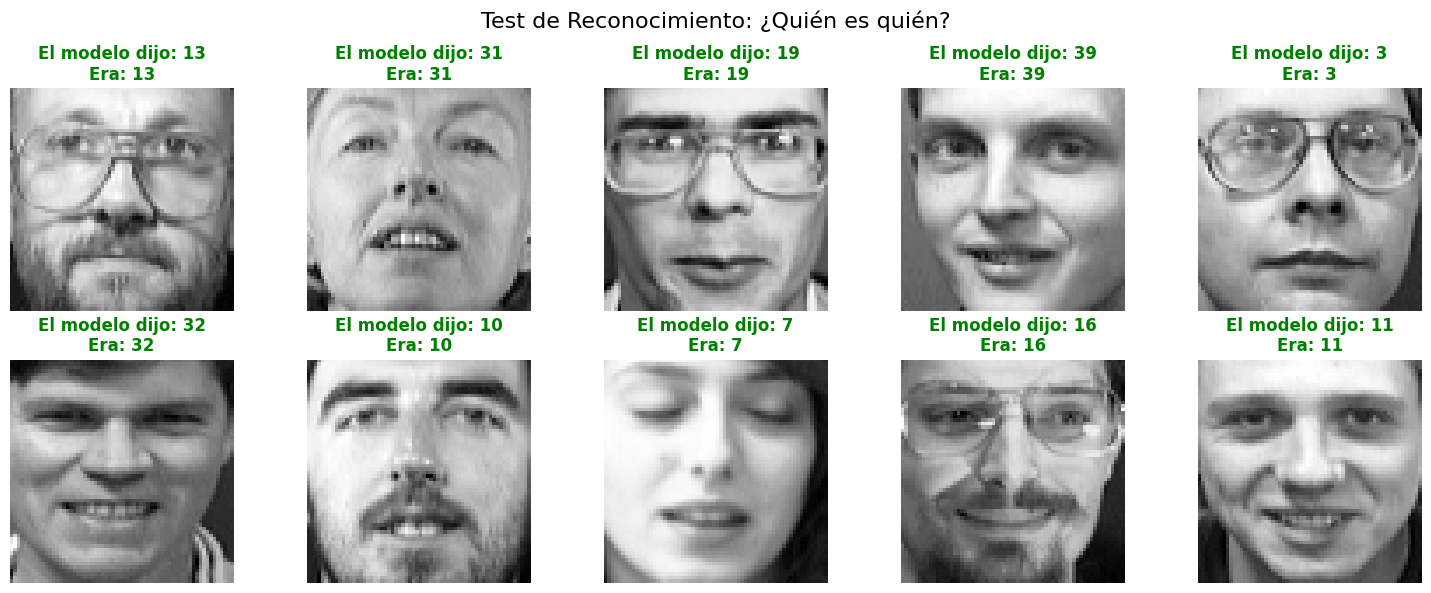

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def visualizar_fotos_predichas(modelo, X_imagenes, X_escaladas, y_reales, cantidad=10):
    """
    Toma el modelo, hace predicciones sobre las X_escaladas, 
    pero grafica las X_imagenes (originales) para que se vean bien.
    """
    # 1. Hacer que la red haga sus predicciones
    probabilidades = modelo.predict(X_escaladas, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)
    
    # 2. Escoger 'cantidad' de índices al azar
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    # 3. Dibujar la cuadrícula
    plt.figure(figsize=(15, 6))
    plt.suptitle("Test de Reconocimiento: ¿Quién es quién?", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        
        # Recuperar la imagen 64x64 de los datos sin escalar
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        pred = predicciones[idx]
        real = y_reales[idx]
        
        # Color verde si el modelo acertó, rojo si falló
        color = 'green' if pred == real else 'red'
        plt.title(f"El modelo dijo: {pred}\nEra: {real}", color=color, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# ==========================================
# EJECUCIÓN CON EL MEJOR MODELO (RANK 1)
# ==========================================

# 1. Recuperamos el modelo Rank 1 desde nuestra tabla df_top3
mejor_iteracion = df_top3.iloc[0]['Iteración']
datos_mejor = next(item for item in resultados if item["Iteración"] == mejor_iteracion)

# 2. Lo reconstruimos con sus parámetros ganadores
mejor_modelo_mlp = build_model(datos_mejor['Perfil'], datos_mejor['LR'], **datos_mejor['kwargs'])
mejor_modelo_mlp.set_weights(datos_mejor['Pesos'])

# 3. Llamamos a la función usando X_test (datos originales) y X_test_scaled (para predecir)
visualizar_fotos_predichas(mejor_modelo_mlp, X_test, X_test_scaled, y_test, cantidad=10)


## ❌ Análisis Visual de Errores

El objetivo de esta sección es la **interpretabilidad**. No basta con saber qué porcentaje falló; necesitamos ver las imágenes donde la IA se equivocó. Esto nos permite identificar si los fallos se deben a:
*   Sombras extremas en el rostro.
*   Uso de accesorios (gafas).
*   Cambios drásticos en la expresión facial o rotación de la cabeza.

Este análisis es fundamental para entender las limitaciones actuales del modelo MLP en comparación con arquitecturas más avanzadas como las Redes Convolucionales (CNN).


Se encontraron 4 errores en total.


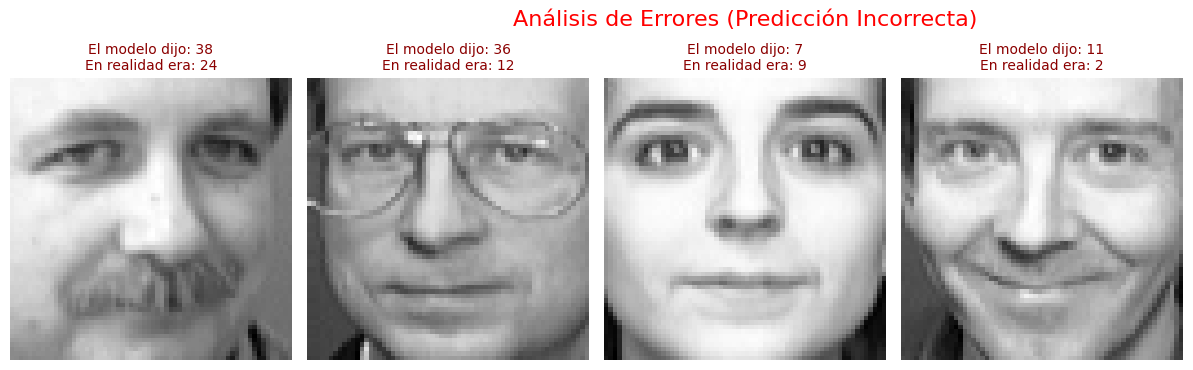

In [30]:
def visualizar_errores_red(modelo, X_imagenes, X_escaladas, y_reales):
    # 1. Hacer predicciones sobre todo el set de prueba
    probabilidades = modelo.predict(X_escaladas, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)
    
    # 2. Encontrar los índices donde el modelo se equivocó
    indices_errores = np.where(predicciones != y_reales)[0]
    
    if len(indices_errores) == 0:
        print("✨ ¡Perfecto! El modelo no cometió ningún error en el conjunto de prueba.")
        return

    print(f"Se encontraron {len(indices_errores)} errores en total.")
    
    # 3. Mostrar los errores (limitamos a 20 por si hay demasiados)
    num_mostrar = min(len(indices_errores), 20)
    columnas = 5
    filas = (num_mostrar // columnas) + (1 if num_mostrar % columnas != 0 else 0)
    
    plt.figure(figsize=(15, 4 * filas))
    plt.suptitle("Análisis de Errores (Predicción Incorrecta)", fontsize=16, color='red')
    
    for i in range(num_mostrar):
        idx = indices_errores[i]
        plt.subplot(filas, columnas, i + 1)
        
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        plt.title(f"El modelo dijo: {predicciones[idx]}\nEn realidad era: {y_reales[idx]}", 
                  color='darkred', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Ejecutar el análisis de errores con tu mejor modelo
visualizar_errores_red(mejor_modelo_mlp, X_test, X_test_scaled, y_test)
